In [1]:
# Install dependencies (run once per environment). Comment this cell out if everything is already installed.
%pip install -q pandas numpy matplotlib seaborn librosa soundfile scikit-learn torch torchaudio torchvision tqdm kaggle ipywidgets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 111.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 32.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 15.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 17.0 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed

In [10]:
import os
import random
import zipfile
import subprocess
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

plt.style.use("seaborn-v0_8")
sns.set_theme(context="notebook")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

from pathlib import Path

PROJECT_ROOT = Path("/content")  # or Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"  # only used for artifacts/checkpoints
DATA_DIR.mkdir(exist_ok=True)

RAW_DATA_ROOT = Path("/kaggle/input/master/ESC-50-master")
META_PATH = RAW_DATA_ROOT / "meta" / "esc50.csv"
AUDIO_DIR = RAW_DATA_ROOT / "audio"

SAMPLE_RATE = 22_050
TARGET_DURATION = 5.0  # seconds
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512
MAX_SAMPLES = int(SAMPLE_RATE * TARGET_DURATION)

BATCH_SIZE = 32
EPOCHS = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0  # Windows-friendly


Using device: cuda


## 4.1 Data Pre-Processing
Menyiapkan subset ESC-50, memverifikasi metadata, dan membangun split train/val/test untuk eksperimen yang konsisten.


In [11]:
ESC50_DATASET_SLUG = "mmoreaux/environmental-sound-classification-50"


def find_esc50_root(base_dir: Path) -> Path:
    """Return the ESC-50 root folder that contains meta/esc50.csv."""
    meta_match = list(base_dir.glob("**/meta/esc50.csv"))
    if meta_match:
        return meta_match[0].parents[1]
    candidate = base_dir / "ESC-50-master"
    if candidate.exists():
        return candidate
    raise FileNotFoundError("ESC-50 folder not found. Run download_esc50().")


In [12]:
META_PATH = RAW_DATA_ROOT / "meta" / "esc50.csv"
AUDIO_DIR = RAW_DATA_ROOT / "audio"

if not META_PATH.exists():
    raise FileNotFoundError(f"Metadata CSV not found at {META_PATH}")
if not AUDIO_DIR.exists():
    raise FileNotFoundError(f"Audio folder not found at {AUDIO_DIR}")

metadata = pd.read_csv(META_PATH)
print(f"Total clips in ESC-50: {len(metadata):,}")
metadata.head()


Total clips in ESC-50: 2,000


,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [13]:
SELECTED_CLASSES = [
    "helicopter",
    "chainsaw",
    "siren",
    "car_horn",
    "engine",
    "train",
    "church_bells",
    "airplane",
    "fireworks",
    "hand_saw"
]

if not (2 <= len(SELECTED_CLASSES) <= 10):
    raise ValueError("Please keep between 2 and 8 labels to satisfy the project scope.")

subset_df = metadata[metadata["category"].isin(SELECTED_CLASSES)].copy()
if subset_df.empty:
    raise ValueError("No rows match SELECTED_CLASSES. Double-check spelling against esc50.csv")

class_to_idx = {cls: idx for idx, cls in enumerate(SELECTED_CLASSES)}
idx_to_class = {v: k for k, v in class_to_idx.items()}
subset_df["target_idx"] = subset_df["category"].map(class_to_idx)

print(f"Clips kept: {len(subset_df)} across {len(SELECTED_CLASSES)} classes")
class_counts = subset_df["category"].value_counts().loc[SELECTED_CLASSES]
class_counts


Clips kept: 400 across 10 classes


category
helicopter      40
chainsaw        40
siren           40
car_horn        40
engine          40
train           40
church_bells    40
airplane        40
fireworks       40
hand_saw        40
Name: count, dtype: int64

## 4.2 Feature Extraction
Transformasi sinyal audio ke mel-spectrogram, normalisasi, dan augmentasi ringan sebelum masuk ke model.


In [14]:
def pad_or_trim(signal: np.ndarray, max_samples: int = MAX_SAMPLES) -> np.ndarray:
    if len(signal) > max_samples:
        return signal[:max_samples]
    if len(signal) < max_samples:
        pad_width = max_samples - len(signal)
        signal = np.pad(signal, (0, pad_width), mode="constant")
    return signal


def waveform_to_mel(signal: np.ndarray, sr: int = SAMPLE_RATE) -> np.ndarray:
    mel = librosa.feature.melspectrogram(
        y=signal,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmax=sr // 2,
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return mel_db


def normalize_mel(mel_db: np.ndarray) -> np.ndarray:
    mean = mel_db.mean()
    std = mel_db.std()
    return (mel_db - mean) / (std + 1e-6)


def random_time_shift(signal: np.ndarray, max_shift: int = 2_000) -> np.ndarray:
    if max_shift <= 0:
        return signal
    shift = np.random.randint(-max_shift, max_shift)
    return np.roll(signal, shift)



In [15]:
class Esc50MelDataset(Dataset):
    def __init__(self, df: pd.DataFrame, audio_dir: Path, augment: bool = False):
        self.df = df.reset_index(drop=True)
        self.audio_dir = Path(audio_dir)
        self.augment = augment

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        row = self.df.iloc[idx]
        file_path = self.audio_dir / row["filename"]
        signal, _ = librosa.load(file_path, sr=SAMPLE_RATE)

        if self.augment:
            signal = random_time_shift(signal)

        signal = pad_or_trim(signal)
        mel = waveform_to_mel(signal)
        mel = normalize_mel(mel)

        mel_tensor = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(row["target_idx"], dtype=torch.long)

        return {
            "input": mel_tensor,
            "label": label,
            "category": row["category"],
            "filename": row["filename"],
        }



In [16]:
train_df, temp_df = train_test_split(
    subset_df,
    test_size=0.3,
    stratify=subset_df["category"],
    random_state=RANDOM_SEED,
)
val_df, _ = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["category"],
    random_state=RANDOM_SEED,
)

print(
    f"Train: {len(train_df)}, Val: {len(val_df)} (test loaded from Drive folder below)"
)

train_dataset = Esc50MelDataset(train_df, AUDIO_DIR, augment=True)
val_dataset = Esc50MelDataset(val_df, AUDIO_DIR, augment=False)

common_loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": device.type == "cuda",
}

train_loader = DataLoader(train_dataset, shuffle=True, **common_loader_kwargs)
val_loader = DataLoader(val_dataset, shuffle=False, **common_loader_kwargs)



Train: 280, Val: 60 (test loaded from Drive folder below)


## 4.3 Visualisasi
Eksplorasi visual untuk distribusi data, contoh mel-spectrogram, dan metrik training.


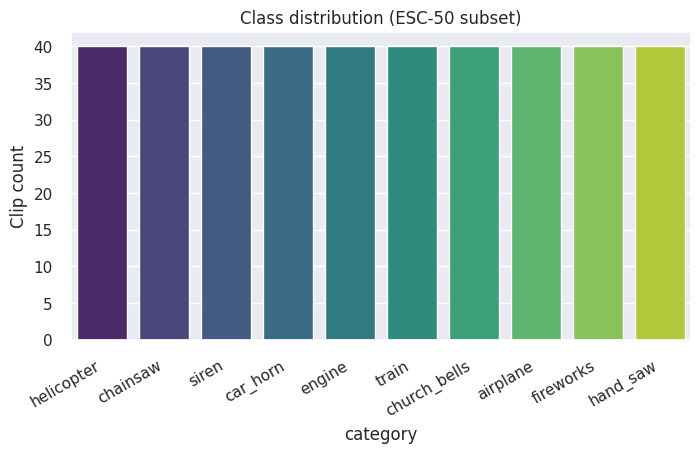

In [17]:
plt.figure(figsize=(8, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Clip count")
plt.title("Class distribution (ESC-50 subset)")
plt.show()


In [20]:
# Build test set from the shared Drive folder (class subfolders with wav files)
TEST_AUDIO_ROOT = Path("/kaggle/input/data-test/data test")
# If you added the folder into MyDrive instead of Shared drives, change to:
# TEST_AUDIO_ROOT = Path("/content/drive/MyDrive/data test")


def build_test_df_from_folder(root: Path, selected_classes: List[str]) -> pd.DataFrame:
    rows: List[Dict[str, str]] = []
    root = Path(root)
    for cls in selected_classes:
        cls_dir = root / cls
        if not cls_dir.exists():
            print(f"Warning: missing folder for class '{cls}': {cls_dir}")
            continue
        for audio_path in cls_dir.glob("*.wav"):
            rows.append({
                "filename": f"{cls}/{audio_path.name}",
                "category": cls,
            })
    if not rows:
        raise ValueError(f"No audio files found under {root}. Check the mount/path.")
    df = pd.DataFrame(rows)
    df["target_idx"] = df["category"].map(class_to_idx)
    return df


external_test_df = build_test_df_from_folder(TEST_AUDIO_ROOT, SELECTED_CLASSES)
print(f"External test clips found: {len(external_test_df)}")

# Override test split to use the external clips
test_df = external_test_df

test_dataset = Esc50MelDataset(test_df, TEST_AUDIO_ROOT, augment=False)
test_loader = DataLoader(test_dataset, shuffle=False, **common_loader_kwargs)


External test clips found: 80


Batch mel shape: torch.Size([32, 1, 128, 216])
Batch labels shape: torch.Size([32])


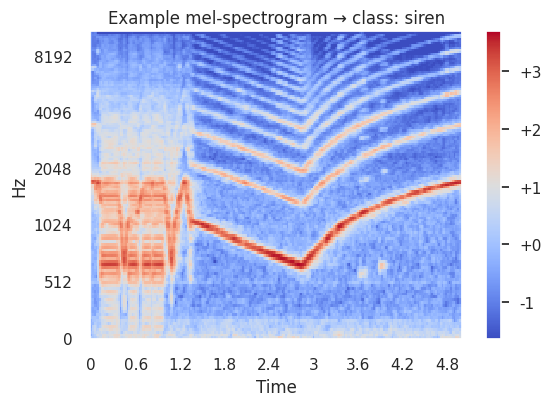

In [21]:
sample_batch = next(iter(train_loader))
inputs = sample_batch["input"]
labels = sample_batch["label"]
print(f"Batch mel shape: {inputs.shape}")
print(f"Batch labels shape: {labels.shape}")

idx = 0
mel_img = inputs[idx, 0].numpy()
plt.figure(figsize=(6, 4))
librosa.display.specshow(mel_img, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis="time", y_axis="mel")
plt.title(f"Example mel-spectrogram → class: {idx_to_class[labels[idx].item()]}")
plt.colorbar(format="%+2.0f")
plt.show()


## 4.4 Modelling
Mendefinisikan arsitektur CNN berbasis mel-spectrogram serta proses training dan evaluasinya.


### 4.4.1 Arsitektur
Kumpulan kandidat model (CNN baseline, ResNet-ish, CRNN, dan HTSAT-22) untuk dibandingkan secara konsisten.


In [22]:
def count_params(model: nn.Module) -> float:
    return sum(p.numel() for p in model.parameters()) / 1e6


class ConvBlock(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        pool_size: Tuple[int, int] = (2, 2),
        dropout: float = 0.1,
    ):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(pool_size),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class SoundClassifier(nn.Module):
    """Baseline CNN (empat blok konvolusi)."""

    def __init__(self, num_classes: int):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            ConvBlock(1, 16, dropout=0.1),
            ConvBlock(16, 32, dropout=0.15),
            ConvBlock(32, 64, dropout=0.2),
            ConvBlock(64, 128, pool_size=(2, 1), dropout=0.25),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.feature_extractor(x)
        return self.classifier(x)


class ResidualBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, stride: Tuple[int, int] = (1, 1)):
        super().__init__()
        self.proj = (
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
            if (in_channels != out_channels or stride != (1, 1))
            else nn.Identity()
        )
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=stride, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.block(x)
        out = out + self.proj(x)
        return self.relu(out)


class ResNetish(nn.Module):
    """ResNet kecil yang cocok untuk input 1-channel."""

    def __init__(self, num_classes: int):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.layer1 = nn.Sequential(ResidualBlock(32, 32), ResidualBlock(32, 32))
        self.layer2 = nn.Sequential(
            ResidualBlock(32, 64, stride=(2, 2)),
            ResidualBlock(64, 64),
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(64, 128, stride=(2, 1)),
            ResidualBlock(128, 128),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


class CRNNClassifier(nn.Module):
    """CNN front-end + bidirectional GRU."""

    def __init__(self, num_classes: int):
        super().__init__()
        self.cnn = nn.Sequential(
            ConvBlock(1, 32, dropout=0.1),
            ConvBlock(32, 64, dropout=0.15),
            ConvBlock(64, 128, pool_size=(2, 1), dropout=0.2),
        )
        self.rnn = nn.GRU(input_size=128, hidden_size=128, num_layers=1, bidirectional=True, batch_first=True)
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(256, num_classes))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.cnn(x)  # (B, C, H, W)
        x = x.mean(dim=2)  # average over mel bins -> (B, C, W)
        x = x.permute(0, 2, 1)  # (B, W, C)
        x, _ = self.rnn(x)
        x = x.mean(dim=1)
        return self.classifier(x)


class HTSAT(nn.Module):
    """Sederhana HTSAT-like: patch embedding + Transformer encoder."""

    def __init__(self, num_classes: int, embed_dim: int = 128, num_heads: int = 4, depth: int = 4, mlp_ratio: float = 2.0, dropout: float = 0.1):
        super().__init__()
        self.patch_embed = nn.Conv2d(1, embed_dim, kernel_size=(4, 4), stride=(4, 4))
        self.pos_embed = None  # dibuat dinamis di forward
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=dropout,
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def _get_pos_embed(self, n_patches: int, embed_dim: int, device: torch.device):
        if self.pos_embed is None or self.pos_embed.shape[1] != n_patches:
            self.pos_embed = nn.Parameter(torch.zeros(1, n_patches, embed_dim, device=device))
            nn.init.trunc_normal_(self.pos_embed, std=0.02)
        return self.pos_embed

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)  # (B, C, H', W')
        b, c, h, w = x.shape
        x = x.flatten(2).transpose(1, 2)  # (B, HW, C)
        pos = self._get_pos_embed(h * w, c, x.device)
        x = x + pos
        x = self.encoder(x)
        x = self.norm(x)
        x = x.mean(dim=1)
        return self.head(x)


MODEL_ZOO = {
    "cnn_baseline": lambda: SoundClassifier(num_classes=len(SELECTED_CLASSES)),
    "resnet_like": lambda: ResNetish(num_classes=len(SELECTED_CLASSES)),
    "crnn": lambda: CRNNClassifier(num_classes=len(SELECTED_CLASSES)),
    "htsat_22": lambda: HTSAT(num_classes=len(SELECTED_CLASSES), embed_dim=128, num_heads=4, depth=4),
    "htsat_22": lambda: HTSAT(num_classes=len(SELECTED_CLASSES), embed_dim=128, num_heads=4, depth=4),
}

MODEL_KEY = "cnn_baseline"  # default model untuk eksplorasi cepat
model = MODEL_ZOO[MODEL_KEY]().to(device)
print(f"Selected model: {MODEL_KEY}")
print(model)
print(f"Model parameters: {count_params(model):.2f} M")


class ResidualBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, stride: Tuple[int, int] = (1, 1)):
        super().__init__()
        self.proj = (
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
            if (in_channels != out_channels or stride != (1, 1))
            else nn.Identity()
        )
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=stride, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.block(x)
        out = out + self.proj(x)
        return self.relu(out)


class ResNetish(nn.Module):
    """ResNet kecil yang cocok untuk input 1-channel."""

    def __init__(self, num_classes: int):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.layer1 = nn.Sequential(ResidualBlock(32, 32), ResidualBlock(32, 32))
        self.layer2 = nn.Sequential(
            ResidualBlock(32, 64, stride=(2, 2)),
            ResidualBlock(64, 64),
        )
        self.layer3 = nn.Sequential(
            ResidualBlock(64, 128, stride=(2, 1)),
            ResidualBlock(128, 128),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


class CRNNClassifier(nn.Module):
    """CNN front-end + bidirectional GRU."""

    def __init__(self, num_classes: int):
        super().__init__()
        self.cnn = nn.Sequential(
            ConvBlock(1, 32, dropout=0.1),
            ConvBlock(32, 64, dropout=0.15),
            ConvBlock(64, 128, pool_size=(2, 1), dropout=0.2),
        )
        self.rnn = nn.GRU(input_size=128, hidden_size=128, num_layers=1, bidirectional=True, batch_first=True)
        self.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(256, num_classes))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.cnn(x)  # (B, C, H, W)
        x = x.mean(dim=2)  # average over mel bins -> (B, C, W)
        x = x.permute(0, 2, 1)  # (B, W, C)
        x, _ = self.rnn(x)
        x = x.mean(dim=1)
        return self.classifier(x)


class MLPBaseline(nn.Module):
    """Pooling + MLP: baseline non-conv untuk perbandingan."""

    def __init__(self, num_classes: int):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d((32, 32))
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.2),
            nn.Linear(32 * 32, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.pool(x)
        return self.mlp(x)


MODEL_ZOO = {
    "cnn_baseline": lambda: SoundClassifier(num_classes=len(SELECTED_CLASSES)),
    "depthwise_cnn": lambda: DepthwiseCNN(num_classes=len(SELECTED_CLASSES)),
    "resnet_like": lambda: ResNetish(num_classes=len(SELECTED_CLASSES)),
    "crnn": lambda: CRNNClassifier(num_classes=len(SELECTED_CLASSES)),
    "mlp_flat": lambda: MLPBaseline(num_classes=len(SELECTED_CLASSES)),
}

MODEL_KEY = "cnn_baseline"  # ubah untuk mencoba model lain
model = MODEL_ZOO[MODEL_KEY]().to(device)
print(f"Selected model: {MODEL_KEY}")
print(model)
print(f"Model parameters: {count_params(model):.2f} M")


Selected model: cnn_baseline
SoundClassifier(
  (feature_extractor): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
        (7): Dropout(p=0.1, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 

### 4.4.2 Training
Fungsi loop epoch, optimisasi, dan eksekusi training utama.


In [23]:
from copy import deepcopy

criterion = nn.CrossEntropyLoss()
EARLY_STOP_PATIENCE = 5
EARLY_STOP_MIN_DELTA = 1e-3

# Hyperparameter candidates per model (lr, weight decay). Extend if needed.
DEFAULT_HPARAMS = [
    {"lr": LEARNING_RATE, "weight_decay": WEIGHT_DECAY},
    {"lr": 5e-4, "weight_decay": 5e-5},
]
HYPERPARAM_GRID = {
    "cnn_baseline": DEFAULT_HPARAMS,
    "resnet_like": DEFAULT_HPARAMS,
    "crnn": DEFAULT_HPARAMS,
    "htsat_22": [
        {"lr": 7e-4, "weight_decay": 1e-4},
        {"lr": 3e-4, "weight_decay": 5e-5},
    ],
}


def build_optimizer(model: nn.Module, lr: float, weight_decay: float):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=3, factor=0.5
    )
    return optimizer, scheduler


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer | None = None,
) -> Tuple[float, float]:
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch in tqdm(loader, leave=False):
        inputs = batch["input"].to(device)
        labels = batch["label"].to(device)

        with torch.set_grad_enabled(is_train):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


def train_model(
    model: nn.Module,
    epochs: int = EPOCHS,
    lr: float = LEARNING_RATE,
    weight_decay: float = WEIGHT_DECAY,
    patience: int = EARLY_STOP_PATIENCE,
    min_delta: float = EARLY_STOP_MIN_DELTA,
) -> Dict[str, List[float]]:
    optimizer, scheduler = build_optimizer(model, lr=lr, weight_decay=weight_decay)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_state = None
    best_val_acc = 0.0
    epochs_no_improve = 0

    for epoch in range(1, epochs + 1):
        print(f"Epoch {epoch}/{epochs}")
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)

        scheduler.step(val_acc)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc + min_delta:
            best_val_acc = val_acc
            best_state = deepcopy(model.state_dict())
            epochs_no_improve = 0
            print(f"→ New best val_acc: {best_val_acc:.3f}")
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (no improv {epochs_no_improve} epochs)")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Loaded best model with val_acc={best_val_acc:.3f}")

    return history


def train_with_hparams(model_name: str, builder) -> Tuple[nn.Module, Dict[str, List[float]]]:
    """Train a model over a small hyperparameter grid and return the best one."""
    grid = HYPERPARAM_GRID.get(model_name, DEFAULT_HPARAMS)
    best_model = None
    best_history = None
    best_val = -float("inf")

    for hp in grid:
        print(f"→ {model_name} | hp={hp}")
        candidate = builder().to(device)
        history = train_model(
            candidate,
            epochs=EPOCHS,
            lr=hp.get("lr", LEARNING_RATE),
            weight_decay=hp.get("weight_decay", WEIGHT_DECAY),
            patience=EARLY_STOP_PATIENCE,
            min_delta=EARLY_STOP_MIN_DELTA,
        )
        val_best = max(history["val_acc"]) if history["val_acc"] else 0.0
        if val_best > best_val:
            best_val = val_best
            best_model = candidate
            best_history = history
            print(f"✓ New best hp for {model_name}: val_acc={val_best:.3f}")

    return best_model, best_history



In [24]:
%%time
model_histories: Dict[str, Dict[str, List[float]]] = {}
trained_models: Dict[str, nn.Module] = {}

# Jalankan empat model utama
train_list = ["cnn_baseline", "resnet_like", "crnn", "htsat_22"]

for name in train_list:
    print(f"\n=== Training {name} (with small hyperparam grid) ===")
    best_model, best_history = train_with_hparams(name, MODEL_ZOO[name])
    model_histories[name] = best_history
    trained_models[name] = best_model
    best_val = max(best_history["val_acc"]) if best_history and best_history.get("val_acc") else 0.0
    print(f"{name}: best val_acc={best_val:.3f}")

# Model & history utama untuk visualisasi/ evaluasi di bawah
model = trained_models[train_list[0]]
history = model_histories[train_list[0]]



=== Training cnn_baseline ===
Epoch 1/30


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

→ New best val_acc: 0.100
Epoch 2/30


  0%|          | 0/9 [00:00<?, ?it/s]

...

  0%|          | 0/2 [00:00<?, ?it/s]

Epoch 30/30


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

Loaded best model with val_acc=0.533
mlp_flat: best val_acc=0.533
CPU times: user 23min 36s, sys: 12.1 s, total: 23min 48s
Wall time: 13min 1s


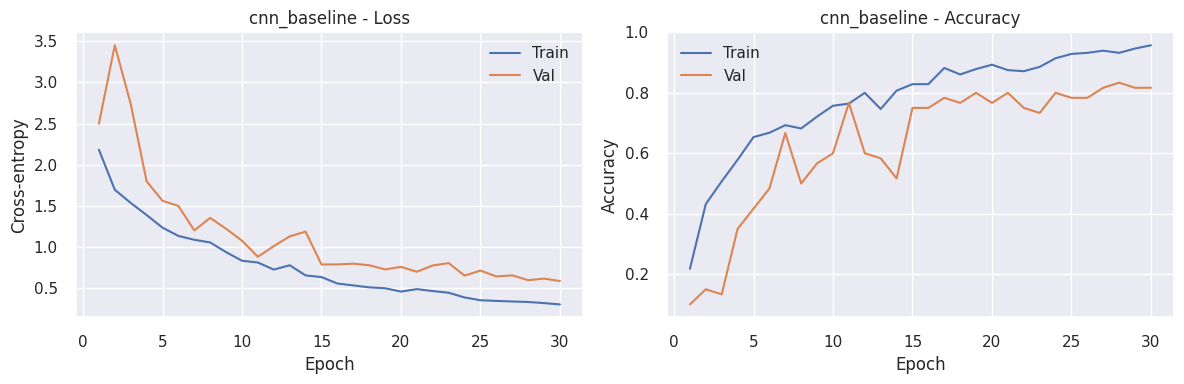

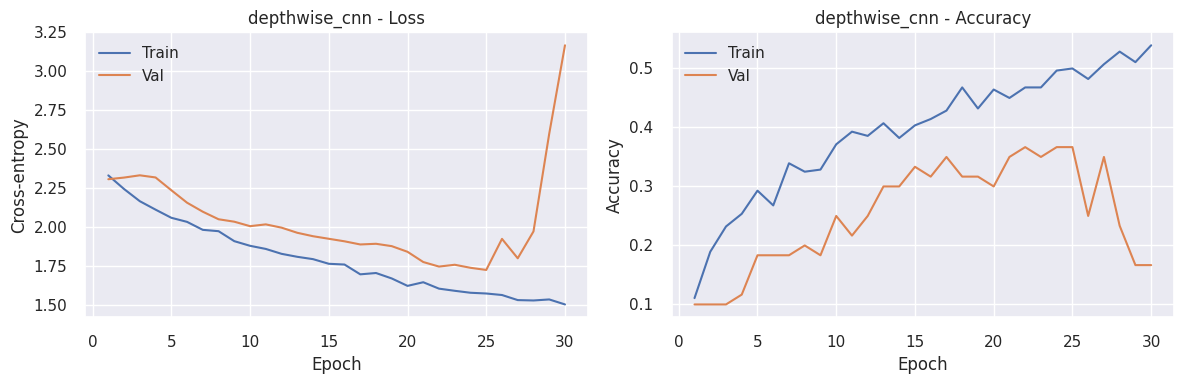

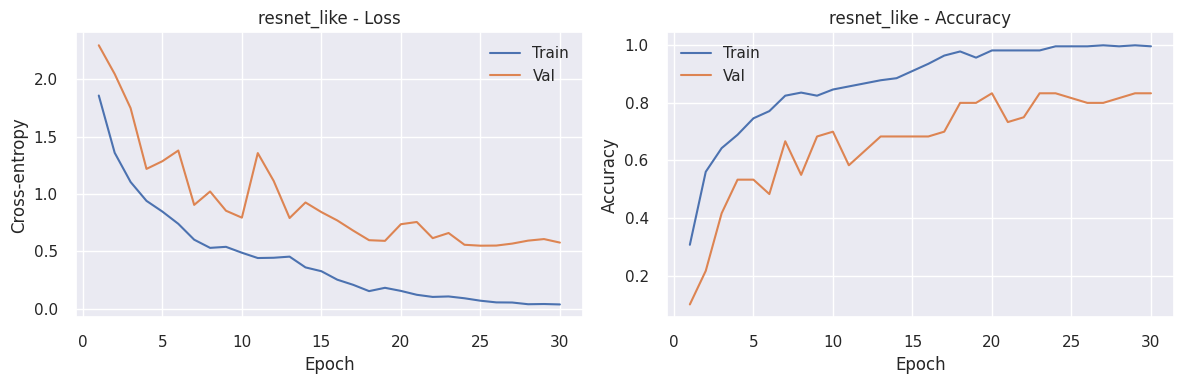

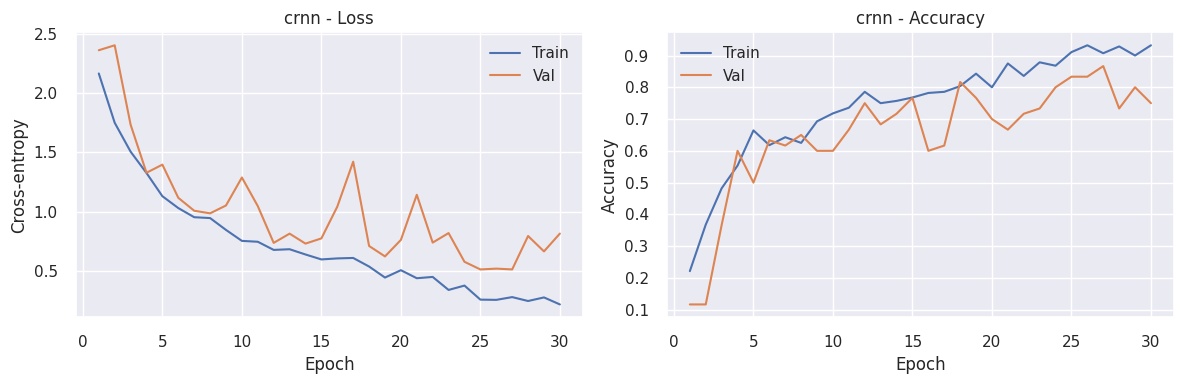

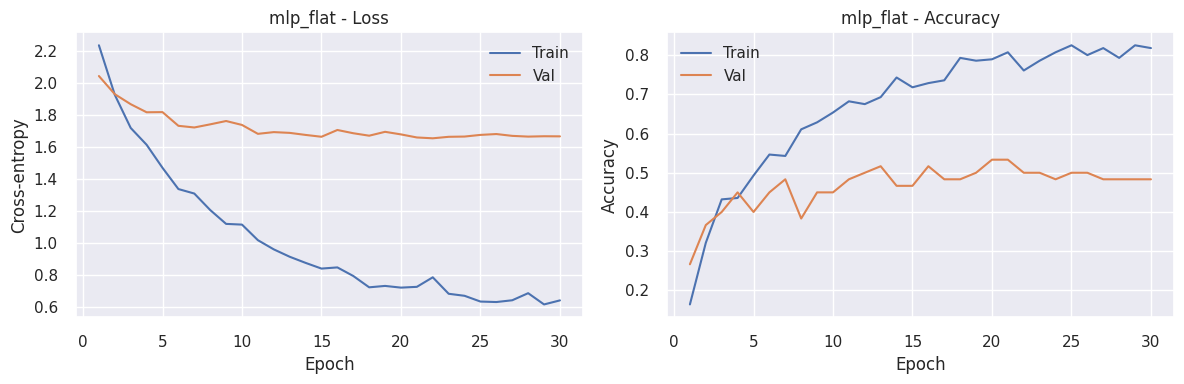

In [ ]:
def plot_history(history: Dict[str, List[float]], title_prefix: str = ""):
    epochs_range = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    title_prefix = f"{title_prefix} - " if title_prefix else ""

    axes[0].plot(epochs_range, history["train_loss"], label="Train")
    axes[0].plot(epochs_range, history["val_loss"], label="Val")
    axes[0].set_title(f"{title_prefix}Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-entropy")
    axes[0].legend()

    axes[1].plot(epochs_range, history["train_acc"], label="Train")
    axes[1].plot(epochs_range, history["val_acc"], label="Val")
    axes[1].set_title(f"{title_prefix}Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# Plot utama
plot_history(history, title_prefix=train_list[0])

# Plot tambahan bila ada lebih banyak model yang dilatih
if len(model_histories) > 1:
    for name, hist in model_histories.items():
        if name == train_list[0]:
            continue
        plot_history(hist, title_prefix=name)


#### Ringkasan kandidat model
Ringkasan cepat akurasi validasi tertinggi dari setiap model yang sempat dilatih pada sel di atas.


In [26]:
summary_rows = []
for name, hist in model_histories.items():
    best_val = max(hist.get("val_acc", []) or [float("nan")])
    last_train = hist.get("train_acc", [])[-1] if hist.get("train_acc") else float("nan")
    summary_rows.append({"model": name, "best_val_acc": best_val, "last_train_acc": last_train})

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values("best_val_acc", ascending=False)
summary_df


,model,best_val_acc,last_train_acc
3,crnn,0.866667,0.932143
0,cnn_baseline,0.833333,0.957143
2,resnet_like,0.833333,0.996429
4,mlp_flat,0.533333,0.817857
1,depthwise_cnn,0.366667,0.539286


### 4.4.3 Evaluasi
Evaluasi model dengan pendekatan chunking untuk audio berdurasi bervariasi.


In [27]:
# === Chunked inference over variable-length test audio (wav/mp3/m4a) ===

AUDIO_EXTENSIONS = (".wav", ".mp3", ".m4a")


def iter_test_files_from_folder(root: Path, selected_classes: List[str]):
    """Yield metadata dicts for all supported audio files under class subfolders."""
    root = Path(root)
    for cls in selected_classes:
        cls_dir = root / cls
        if not cls_dir.exists():
            print(f"Warning: missing folder for class '{cls}': {cls_dir}")
            continue
        for audio_path in cls_dir.iterdir():
            if not audio_path.is_file():
                continue
            if audio_path.suffix.lower() not in AUDIO_EXTENSIONS:
                continue
            yield {
                "filepath": audio_path,
                "filename": f"{cls}/{audio_path.name}",
                "category": cls,
                "target_idx": class_to_idx[cls],
            }


def chunk_signal(
    signal: np.ndarray,
    sr: int = SAMPLE_RATE,
    chunk_duration: float = TARGET_DURATION,
    overlap: float = 0.5,
) -> List[np.ndarray]:
    """Split signal into overlapping chunks of fixed duration.

    Returns a list of 1D numpy arrays, each at most MAX_SAMPLES long.
    """
    max_samples = int(sr * chunk_duration)
    if max_samples <= 0:
        return [signal]

    if len(signal) <= max_samples:
        return [pad_or_trim(signal, max_samples)]

    step = int(max_samples * (1.0 - overlap))
    step = max(1, min(step, max_samples))

    chunks: List[np.ndarray] = []
    start = 0
    end_limit = len(signal) - max_samples
    while start <= end_limit:
        chunk = signal[start : start + max_samples]
        chunks.append(chunk)
        start += step

    # Ensure we include the tail of the clip
    if end_limit > 0 and (len(signal) - max_samples) not in range(0, start, step):
        tail_start = len(signal) - max_samples
        chunks.append(signal[tail_start : tail_start + max_samples])

    return [pad_or_trim(c, max_samples) for c in chunks]



def collect_predictions_chunked(
    model: nn.Module,
    root: Path,
    selected_classes: List[str],
    overlap: float = 0.5,
):
    """Run chunked inference over all audio files in the given folder tree.

    For each file we:
      - load the full waveform
      - split into overlapping 5-second chunks
      - classify each chunk
      - average the softmax probabilities across chunks
    """
    model.eval()

    y_true, y_pred, y_prob = [], [], []
    filenames, categories = [], []

    with torch.no_grad():
        for item in tqdm(
            list(iter_test_files_from_folder(root, selected_classes)),
            desc="Evaluating (chunked)",
        ):
            audio_path: Path = item["filepath"]
            try:
                signal, _ = librosa.load(audio_path, sr=SAMPLE_RATE)
            except Exception as e:
                print(f"Error loading {audio_path}: {e}")
                continue

            chunks = chunk_signal(
                signal,
                sr=SAMPLE_RATE,
                chunk_duration=TARGET_DURATION,
                overlap=overlap,
            )
            if not chunks:
                continue

            mel_batch = []
            for sig in chunks:
                mel = waveform_to_mel(sig)
                mel = normalize_mel(mel)
                mel_batch.append(mel)

            mel_batch = np.stack(mel_batch, axis=0)  # [num_chunks, n_mels, time]
            inputs = (
                torch.tensor(mel_batch, dtype=torch.float32)
                .unsqueeze(1)
                .to(device)
            )

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)  # [num_chunks, n_classes]
            mean_probs = probs.mean(dim=0)  # [n_classes]
            pred = mean_probs.argmax().item()

            y_true.append(item["target_idx"])
            y_pred.append(pred)
            y_prob.append(mean_probs.cpu().numpy())
            filenames.append(item["filename"])
            categories.append(item["category"])

    return (
        np.array(y_true),
        np.array(y_pred),
        np.vstack(y_prob) if y_prob else np.empty((0, len(SELECTED_CLASSES))),
        filenames,
        categories,
    )


# Run chunked evaluation on the external test folder (supports wav/mp3/m4a)
chunked_results: Dict[str, Dict[str, np.ndarray | float]] = {}
first_cm_payload = None

for name, mdl in trained_models.items():
    print(f"\n=== Chunked eval for {name} ===")
    (
        y_true_chunk,
        y_pred_chunk,
        y_prob_chunk,
        test_files_chunk,
        test_categories_chunk,
    ) = collect_predictions_chunked(
        mdl,
        TEST_AUDIO_ROOT,
        SELECTED_CLASSES,
        overlap=0.5,
    )

    if len(y_true_chunk) > 0:
        test_acc_chunk = (y_true_chunk == y_pred_chunk).mean()
    else:
        test_acc_chunk = float("nan")

    print(f"Chunked test accuracy: {test_acc_chunk:.3f}")
    print(
        classification_report(
            y_true_chunk,
            y_pred_chunk,
            target_names=SELECTED_CLASSES,
            digits=4,
        )
    )

    chunked_results[name] = {
        "y_true": y_true_chunk,
        "y_pred": y_pred_chunk,
        "y_prob": y_prob_chunk,
        "files": test_files_chunk,
        "acc": test_acc_chunk,
    }

    # Simpan confusion matrix payload untuk visualisasi satu model (yang pertama)
    if first_cm_payload is None and len(y_true_chunk) > 0:
        first_cm_payload = (y_true_chunk, y_pred_chunk)

if first_cm_payload is not None:
    y_true_chunk, y_pred_chunk = first_cm_payload
else:
    y_true_chunk = y_pred_chunk = np.array([])


Evaluating (chunked):   0%|          | 0/91 [00:00<?, ?it/s]

/tmp/ipykernel_47/2361815531.py:90: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(audio_path, sr=SAMPLE_RATE)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/tmp/ipykernel_47/2361815531.py:90: UserWarning: PySoundFile failed. Trying audioread instead.
  signal, _ = librosa.load(audio_path, sr=SAMPLE_RATE)
/usr/local/lib/python3.11/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Chunked test accuracy: 0.681
              precision    recall  f1-score   support

  helicopter     0.6000    0.9000    0.7200        10
    chainsaw     1.0000    1.0000    1.0000         8
       siren     1.0000    0.2000    0.3333        10
    car_horn     0.6923    1.0000    0.8182         9
      engine     0.2500    0.2000    0.2222         5
       train     0.4286    0.3000    0.3529        10
church_bells     0.5714    0.8000    0.6667        10
    airplane     0.3750    0.3333    0.3529         9
   fireworks     1.0000    1.0000    1.0000        10
    hand_saw     0.9000    0.9000    0.9000        10

    accuracy                         0.6813        91
   macro avg     0.6817    0.6633    0.6366        91
weighted avg     0.7017    0.6813    0.6525        91



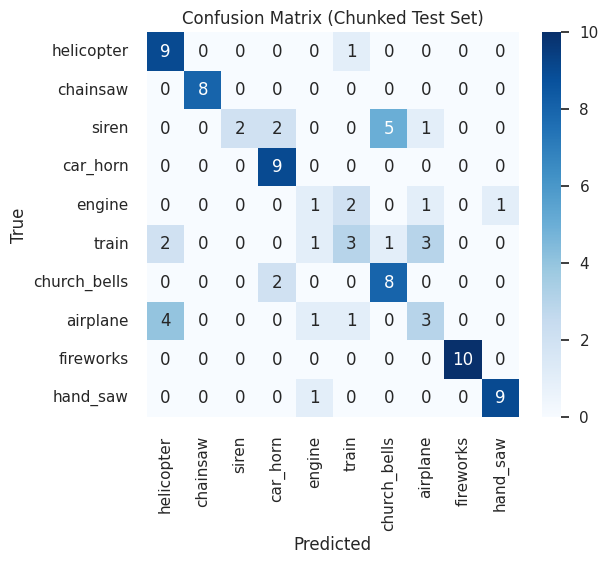

In [28]:
if len(y_true_chunk) == 0:
    print("No chunked predictions available to plot.")
else:
    cm = confusion_matrix(y_true_chunk, y_pred_chunk)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=SELECTED_CLASSES,
        yticklabels=SELECTED_CLASSES,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix (Chunked Test Set)")
    plt.show()


File: engine/Car Engine Start Sound Effect.wav
True label: engine
Predicted: train (31.32%)


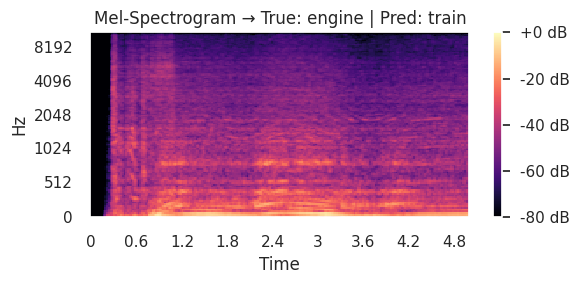

,class,probability
5,train,0.313244
7,airplane,0.162191
3,car_horn,0.153314
1,chainsaw,0.143072
4,engine,0.113512
0,helicopter,0.052319
6,church_bells,0.023139
8,fireworks,0.016668
9,hand_saw,0.012319
2,siren,0.010223


------------------------------------------------------------
File: helicopter/Helicopter Sound Effect.wav
True label: helicopter
Predicted: engine (53.40%)


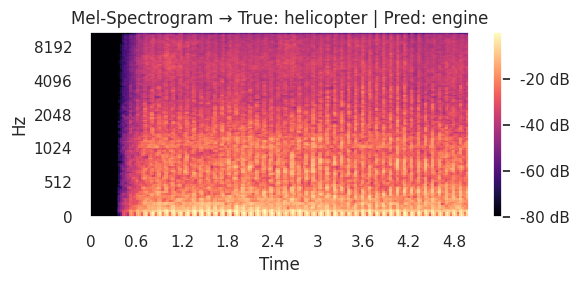

,class,probability
4,engine,0.533992
0,helicopter,0.380040
1,chainsaw,0.056196
8,fireworks,0.008827
3,car_horn,0.007080
7,airplane,0.005643
2,siren,0.004183
9,hand_saw,0.001851
5,train,0.001726
6,church_bells,0.000462


------------------------------------------------------------
File: siren/Siren 10.wav
True label: siren
Predicted: church_bells (52.22%)


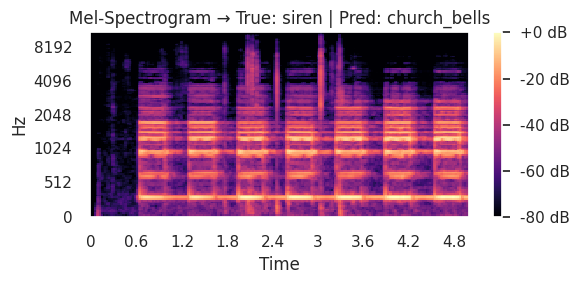

,class,probability
6,church_bells,0.522210
9,hand_saw,0.202123
2,siren,0.081679
3,car_horn,0.060036
8,fireworks,0.058016
1,chainsaw,0.019562
5,train,0.018362
4,engine,0.016513
7,airplane,0.013732
0,helicopter,0.007766


------------------------------------------------------------


In [29]:
def predict_clip(model: nn.Module, file_path: Path) -> Tuple[str, float, np.ndarray]:
    signal, _ = librosa.load(file_path, sr=SAMPLE_RATE)
    signal = pad_or_trim(signal)
    mel = waveform_to_mel(signal)
    mel = normalize_mel(mel)
    tensor = torch.tensor(mel, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_idx = probs.argmax()
    return idx_to_class[pred_idx], probs[pred_idx], probs


def show_sample_predictions(num_samples: int = 4):
    samples = test_df.sample(num_samples, random_state=RANDOM_SEED)
    for _, row in samples.iterrows():
        file_path = TEST_AUDIO_ROOT / row["filename"]
        pred_label, pred_conf, probs = predict_clip(model, file_path)
        true_label = row["category"]

        print(f"File: {row['filename']}")
        print(f"True label: {true_label}")
        print(f"Predicted: {pred_label} ({pred_conf:.2%})")

        plt.figure(figsize=(6, 3))
        mel = waveform_to_mel(pad_or_trim(librosa.load(file_path, sr=SAMPLE_RATE)[0]))
        librosa.display.specshow(mel, sr=SAMPLE_RATE, hop_length=HOP_LENGTH, x_axis="time", y_axis="mel")
        plt.title(f"Mel-Spectrogram → True: {true_label} | Pred: {pred_label}")
        plt.colorbar(format="%+2.0f dB")
        plt.tight_layout()
        plt.show()

        prob_df = pd.DataFrame({"class": SELECTED_CLASSES, "probability": probs})
        prob_df = prob_df.sort_values("probability", ascending=False)
        display(prob_df)
        print("-" * 60)


show_sample_predictions(num_samples=3)
